# MedSAM (ViT-B) Zero-Shot Baseline — Full Pipeline
**Project:** MoE-RenalSAM-CG | **Institution:** BRAC University  
**Purpose:** Evaluate the zero-shot segmentation capability of MedSAM on the out-of-distribution RenSeg-KidneyCT dataset.

This notebook implements:
1. Loading the frozen MedSAM ViT-B checkpoint
2. Running Automatic Mask Generation (AMG) over the full test set
3. Oracle mask selection against expert ground truth
4. Per-class metric computation (Dice, IoU, HD95, Precision, Recall, F1)
5. Publication-quality visualizations (bar charts, radar plots, qualitative grids)

> **Key Thesis:** While MedSAM is fine-tuned on medical data, its zero-shot performance on unseen specific renal pathologies (tiny stones, complex tumors) may still exhibit a Generalization Gap compared to task-specific weakly-supervised models like MoE-RenalSAM-CG.

In [1]:
!pip install -q segment-anything opencv-python matplotlib seaborn tqdm pandas scipy gdown

## 1. Imports & Configuration

In [2]:
import os, warnings, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from scipy.ndimage import distance_transform_edt

import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Setup
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f'Device: {DEVICE}')

# Paths
# Adjust Path(os.getcwd()) if running from a different directory
PROJECT_ROOT = Path(os.getcwd()).parent 
MEDSAM_CKPT = PROJECT_ROOT / 'weights' / 'medsam_vit_b.pth'
RESULTS_DIR = PROJECT_ROOT / 'data' / 'processed' / 'reports' / 'baselines_zeroshot'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['Normal', 'Tumor', 'Stone']
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

# Verification
if not MEDSAM_CKPT.exists():
    print(f"❌ ERROR: MedSAM weights NOT found at: {MEDSAM_CKPT}")
    print("Please ensure the file 'medsam_vit_b.pth' is in the 'weights' folder.")
else:
    file_size = MEDSAM_CKPT.stat().st_size / (1024 * 1024)
    print(f"✅ MedSAM weights verified: {MEDSAM_CKPT} ({file_size:.2f} MB)")


Device: cuda
PROJECT_ROOT: D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG
✅ MedSAM weights verified: D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\weights\medsam_vit_b.pth (357.67 MB)


## 2. Load MedSAM (ViT-B) — Frozen, No Fine-Tuning

In [3]:
medsam = sam_model_registry['vit_b'](checkpoint=str(MEDSAM_CKPT))
medsam = medsam.to(DEVICE)
medsam.eval()

# Freeze all parameters (strict zero-shot)
for p in medsam.parameters():
    p.requires_grad = False

total_params = sum(p.numel() for p in medsam.parameters())
print(f'MedSAM ViT-B loaded | Total params: {total_params:,} | All frozen (zero-shot)')

# Updated Mask Generator: Relaxed thresholds for medical zero-shot sensitivity
mask_generator = SamAutomaticMaskGenerator(
    model=medsam,
    points_per_side=32,
    pred_iou_thresh=0.40,       # Lowered from 0.80 to capture more medical features
    stability_score_thresh=0.50, # Lowered from 0.85
    crop_n_layers=0,             # Disable cropping to avoid internal IndexErrors
    min_mask_region_area=50,     # Allow smaller objects like stones
)
print('SamAutomaticMaskGenerator (MedSAM) ready with optimized medical configuration.')


MedSAM ViT-B loaded | Total params: 93,735,472 | All frozen (zero-shot)
SamAutomaticMaskGenerator (MedSAM) ready with optimized medical configuration.


## 3. Load Test Dataset (RenSeg-KidneyCT)

In [4]:
test_csv = PROJECT_ROOT / 'data' / 'splits' / 'test_manifest.csv'
test_df = pd.read_csv(test_csv)
if 'class_name' in test_df.columns:
    test_df = test_df.rename(columns={'class_name': 'class'})

print(f'Test images: {len(test_df)}')
print(test_df['class'].value_counts())

Test images: 1749
class
Normal    1016
Tumor      457
Stone      276
Name: count, dtype: int64


## 4. Metric Functions

In [5]:
def compute_metrics(pred, gt, pixel_spacing_mm=0.5):
    p = (pred > 0).astype(bool).ravel()
    g = (gt   > 0).astype(bool).ravel()
    if not p.any() and not g.any():
        return {'dice':1.0,'iou':1.0,'hd95':0.0,'precision':1.0,'recall':1.0,'f1':1.0}
    tp = np.logical_and(p,  g).sum()
    fp = np.logical_and(p, ~g).sum()
    fn = np.logical_and(~p, g).sum()
    dice      = (2*tp) / (2*tp + fp + fn + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = (2*precision*recall) / (precision + recall + 1e-8)
    pred_2d = pred.reshape(gt.shape) > 0
    gt_2d   = gt > 0
    if pred_2d.any() and gt_2d.any():
        dt_p = distance_transform_edt(~pred_2d) * pixel_spacing_mm
        dt_g = distance_transform_edt(~gt_2d)   * pixel_spacing_mm
        hd95 = float(np.percentile(np.concatenate([dt_g[pred_2d], dt_p[gt_2d]]), 95))
    else:
        hd95 = float(np.sqrt(gt.shape[0]**2 + gt.shape[1]**2) * pixel_spacing_mm)
    return {k: round(float(v),4) for k,v in
            {'dice':dice,'iou':iou,'hd95':hd95,'precision':precision,'recall':recall,'f1':f1}.items()}

print('Metric functions ready.')

Metric functions ready.


## 5. Zero-Shot Inference (AMG) & Oracle Evaluation
For each test image we:
1. Run `SamAutomaticMaskGenerator` to produce all candidate masks.
2. Select the **oracle-best** mask (highest Dice vs expert GT) — this gives MedSAM its *best possible* score.
3. Record per-image metrics.

In [6]:
records = []
num_masks_list = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc='MedSAM Zero-Shot'):
    img_rel  = str(row['image_path']).replace('\\', '/')
    mask_rel = str(row['expert_mask_path']).replace('\\', '/')
    img_path  = PROJECT_ROOT / img_rel
    mask_path = PROJECT_ROOT / mask_rel
    cls_name  = row['class']

    if not img_path.exists() or not mask_path.exists():
        continue

    image = cv2.imread(str(img_path))
    if image is None:
        continue
        
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Per-image intensity normalization to 0-255 (Crucial for MedSAM features)
    img_min, img_max = image_rgb.min(), image_rgb.max()
    if img_max > img_min:
        image_rgb = ((image_rgb - img_min) / (img_max - img_min) * 255.0).astype(np.uint8)
    
    expert = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if expert is None:
        expert = np.zeros(image.shape[:2], dtype=np.uint8)

    # Run AMG with error handling for the SAM internal IndexError
    masks = []
    try:
        with torch.no_grad():
            masks = mask_generator.generate(image_rgb)
    except IndexError:
        # This catches the "too many indices for tensor of dimension 1" bug
        print(f"⚠️ Warning: SAM internal error on image {row['image_path']}. Skipping AMG for this image.")
        masks = []
    except Exception as e:
        print(f"⚠️ Unexpected error on {row['image_path']}: {e}")
        masks = []
        
    num_masks_list.append(len(masks))

    # Oracle: pick the mask with highest Dice vs expert GT
    best_dice = -1.0
    best_metrics = None
    
    # If no masks were found or a crash occurred, record a zero-score result
    if len(masks) == 0 or not (expert > 0).any():
        best_metrics = compute_metrics(np.zeros_like(expert), expert)
    else:
        for m in masks:
            seg = m['segmentation'].astype(np.uint8) * 255
            d = compute_metrics(seg, expert)['dice']
            if d > best_dice:
                best_dice = d
                best_metrics = compute_metrics(seg, expert)

    # Ensure best_metrics is initialized (in case of empty masks and empty expert)
    if best_metrics is None:
        best_metrics = compute_metrics(np.zeros_like(expert), expert)

    best_metrics['image_id'] = Path(row['image_path']).stem
    best_metrics['class'] = cls_name
    best_metrics['n_masks'] = len(masks)
    records.append(best_metrics)

df_results = pd.DataFrame(records)
df_results.to_csv(RESULTS_DIR / 'medsam_zeroshot_detailed.csv', index=False)
print(f'\n✅ Inference complete. {len(df_results)} images evaluated.')
print(f'Average masks per image: {np.mean(num_masks_list):.1f}')


MedSAM Zero-Shot:   0%|          | 0/1749 [00:00<?, ?it/s]


✅ Inference complete. 1749 images evaluated.
Average masks per image: 119.4


## 6. Per-Class Results Summary

In [7]:
metric_cols = ['dice','iou','hd95','precision','recall','f1']

summary_rows = []
for cls in CLASSES:
    sub = df_results[df_results['class'] == cls]
    if len(sub) == 0:
        continue
    row = {'Class': cls, 'N': len(sub)}
    for m in metric_cols:
        row[f'{m}_mean'] = round(sub[m].mean(), 4)
        row[f'{m}_std']  = round(sub[m].std(), 4)
    summary_rows.append(row)

# Macro average
macro = {'Class': 'MACRO', 'N': len(df_results)}
for m in metric_cols:
    macro[f'{m}_mean'] = round(np.mean([r[f'{m}_mean'] for r in summary_rows]), 4)
    macro[f'{m}_std'] = '---'
summary_rows.append(macro)

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(RESULTS_DIR / 'medsam_zeroshot_summary.csv', index=False)
display(df_summary)

,Class,N,dice_mean,dice_std,iou_mean,iou_std,hd95_mean,hd95_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Normal,1016,1.0000,0.0,1.0000,0.0,0.0000,0.0,1.0000,0.0,1.0000,0.0,1.0000,0.0
1,Tumor,457,0.1899,0.2248,0.1278,0.1873,47.3255,33.8084,0.3772,0.3793,0.2119,0.2438,0.1899,0.2248
2,Stone,276,0.0542,0.1633,0.0382,0.1248,95.2828,60.6509,0.0814,0.2444,0.2510,0.3344,0.0542,0.1633
3,MACRO,1749,0.4147,---,0.3887,---,47.5361,---,0.4862,---,0.4876,---,0.4147,---


## 7. Visualization: Per-Class Dice Scores

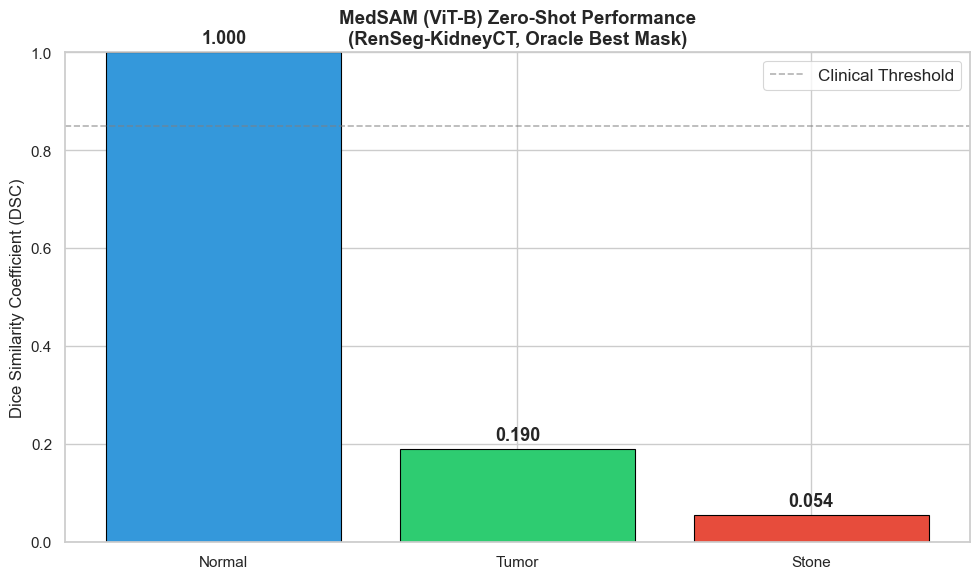

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_context('paper', font_scale=1.4)

plot_df = df_summary[df_summary['Class'] != 'MACRO'].copy()
colors = {'Normal': '#3498db', 'Tumor': '#2ecc71', 'Stone': '#e74c3c'}
bars = ax.bar(plot_df['Class'], plot_df['dice_mean'],
              color=[colors.get(c, 'gray') for c in plot_df['Class']],
              edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, plot_df['dice_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Dice Similarity Coefficient (DSC)')
ax.set_title('MedSAM (ViT-B) Zero-Shot Performance\n(RenSeg-KidneyCT, Oracle Best Mask)', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.6, label='Clinical Threshold')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'medsam_zeroshot_dice_bar.png', dpi=300)
plt.show()

## 8. Visualization: Multi-Metric Radar Chart

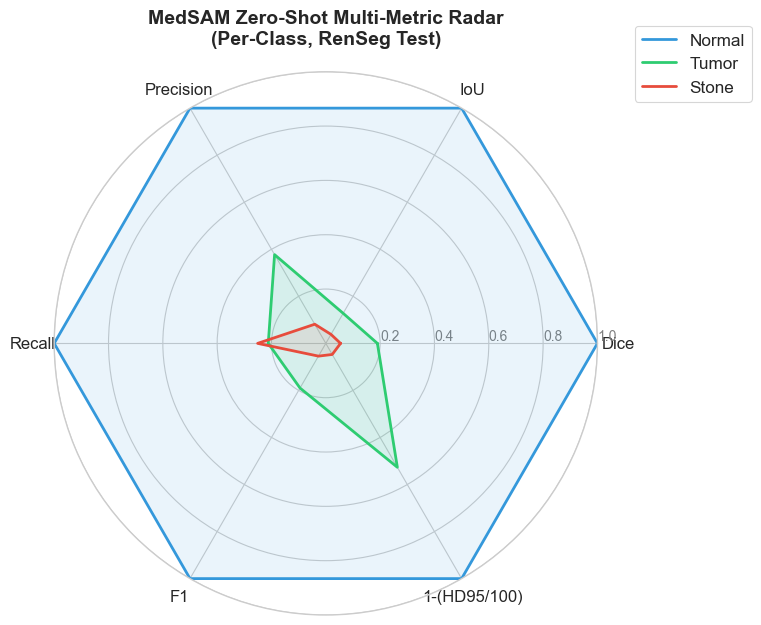

In [9]:
def radar_plot(df_summary, save_path):
    categories = ['Dice','IoU','Precision','Recall','F1','1-(HD95/100)']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    ax.set_rlabel_position(0)
    plt.yticks([0.2,0.4,0.6,0.8,1.0], color='grey', size=10)
    plt.ylim(0,1.0)

    color_map = {'Normal':'#3498db','Tumor':'#2ecc71','Stone':'#e74c3c'}
    for _, row in df_summary.iterrows():
        if row['Class'] == 'MACRO':
            continue
        hd95_norm = max(0, 1 - (row['hd95_mean'] / 100.0))
        vals = [row['dice_mean'], row['iou_mean'], row['precision_mean'],
                row['recall_mean'], row['f1_mean'], hd95_norm]
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=row['Class'], color=color_map.get(row['Class'],'gray'))
        ax.fill(angles, vals, alpha=0.1, color=color_map.get(row['Class'],'gray'))

    plt.xticks(angles[:-1], categories, size=12)
    plt.title('MedSAM Zero-Shot Multi-Metric Radar\n(Per-Class, RenSeg Test)', size=14, pad=20, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

radar_plot(df_summary, RESULTS_DIR / 'medsam_zeroshot_radar.png')

## 9. Qualitative Visualization (Worst & Best Cases)

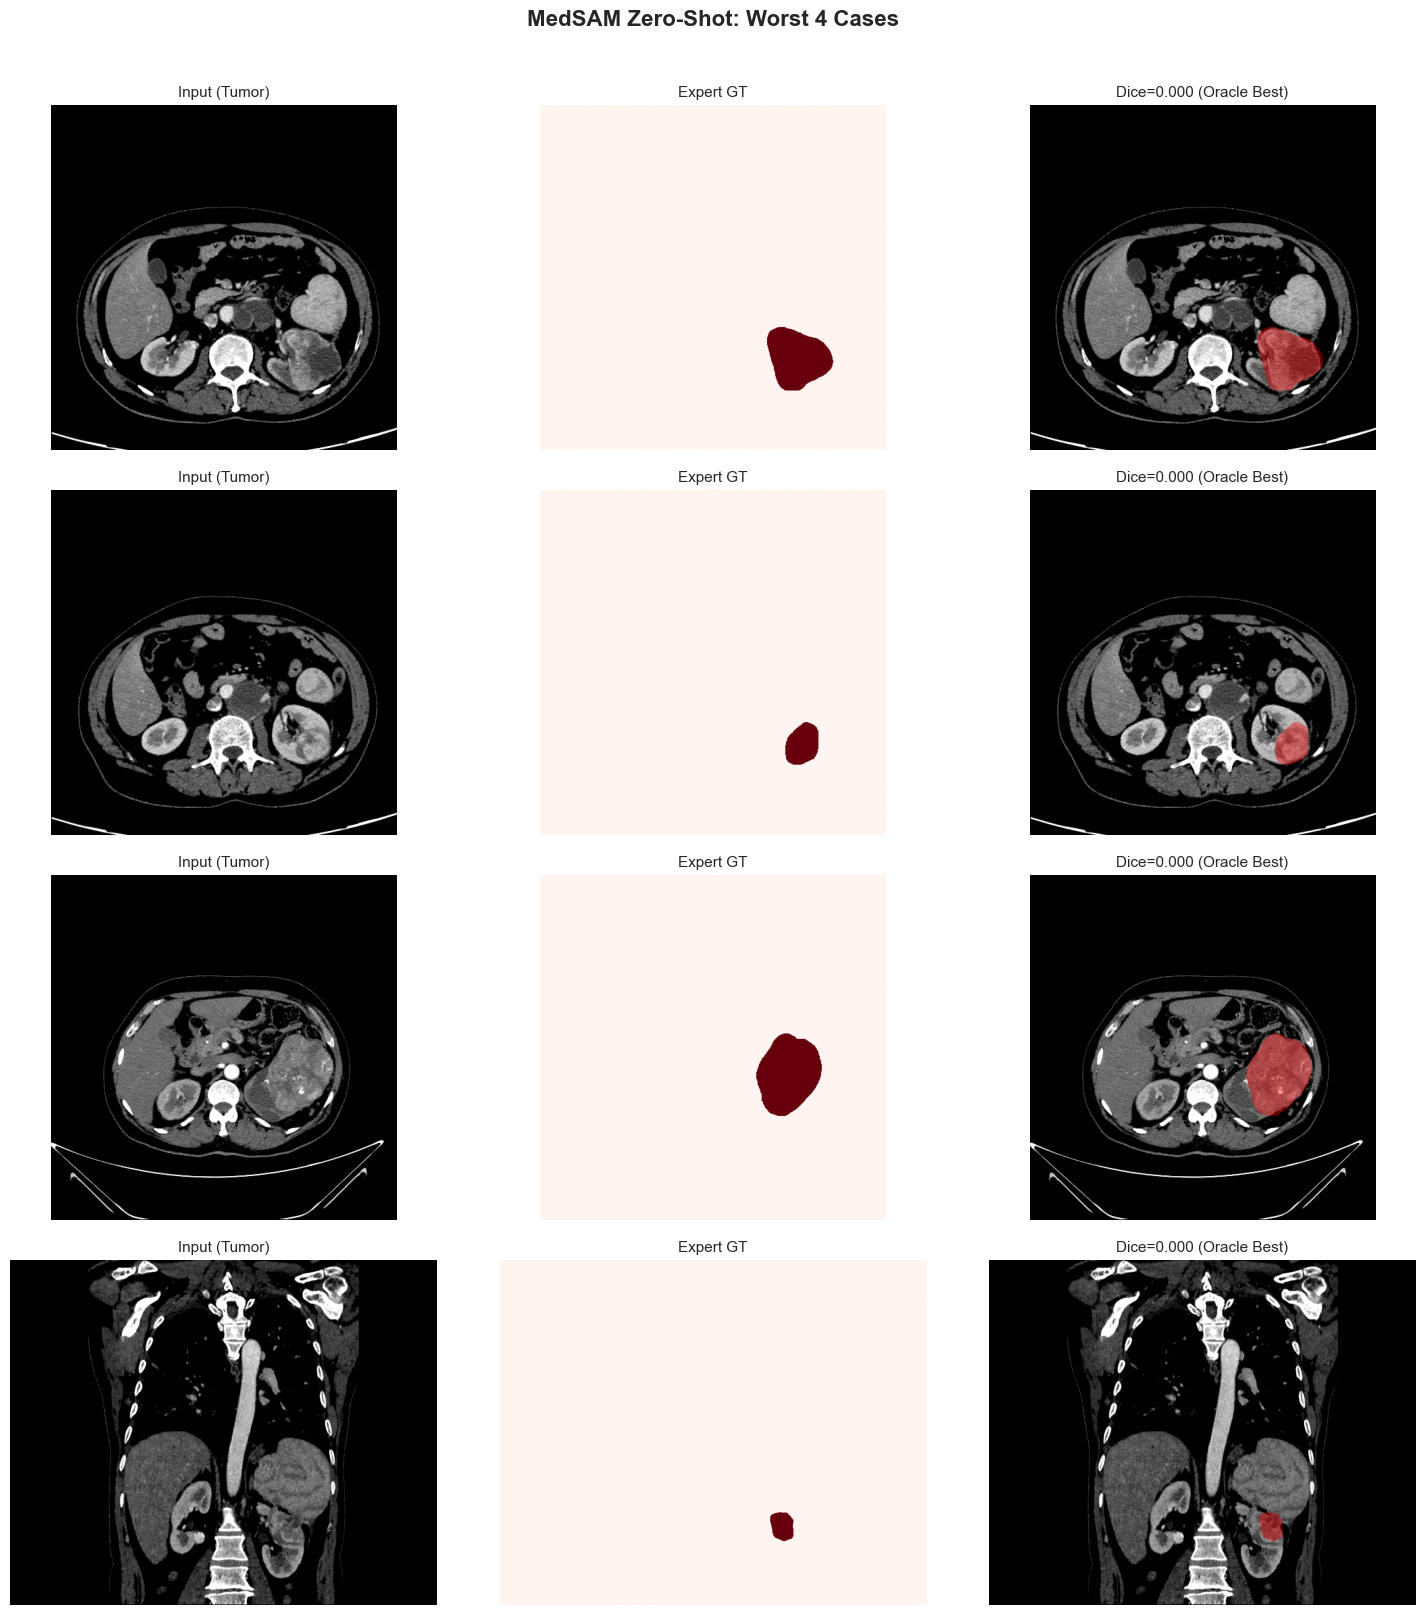

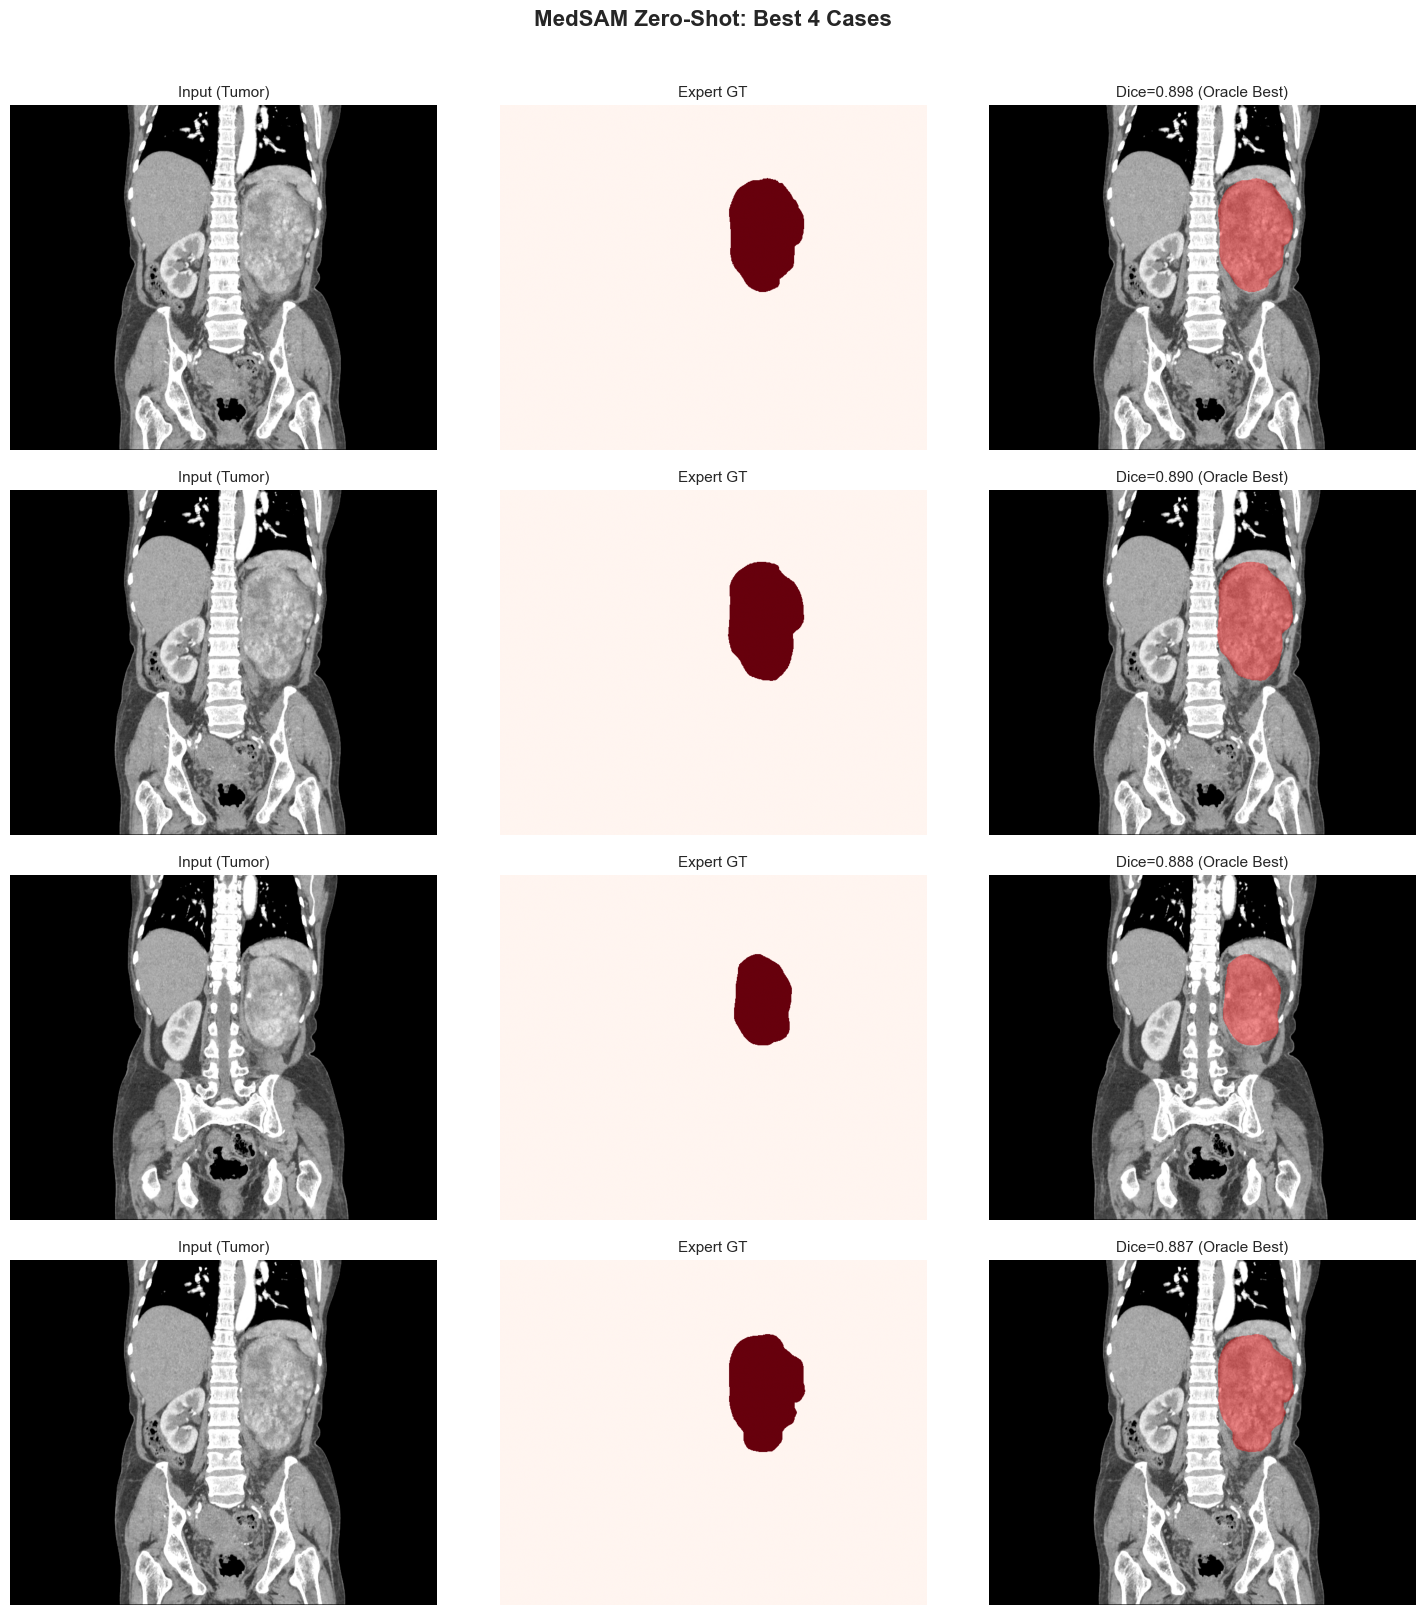

In [10]:
def show_qualitative(df_res, tdf, n=4, mode='worst'):
    sub = df_res[df_res['class'].isin(['Tumor','Stone'])].copy()
    if mode == 'worst':
        sub = sub.nsmallest(n, 'dice')
    else:
        sub = sub.nlargest(n, 'dice')

    fig, axes = plt.subplots(n, 3, figsize=(15, 4*n))
    if n == 1:
        axes = axes[np.newaxis, :]
    
    for i, (_, row) in enumerate(sub.iterrows()):
        orig = tdf[tdf['image_path'].apply(lambda x: Path(x).stem) == row['image_id']]
        if len(orig) == 0:
            continue
        orig = orig.iloc[0]
        
        ip = PROJECT_ROOT / str(orig['image_path']).replace('\\', '/')
        mp = PROJECT_ROOT / str(orig['expert_mask_path']).replace('\\', '/')
        
        img = cv2.imread(str(ip))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.zeros((512,512,3), dtype=np.uint8)
        expert = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if expert is None:
            expert = np.zeros(img.shape[:2], dtype=np.uint8)
            
        axes[i,0].imshow(img)
        axes[i,0].set_title(f'Input ({row["class"]})', fontsize=11)
        axes[i,0].axis('off')
        
        axes[i,1].imshow(expert, cmap='Reds')
        axes[i,1].set_title('Expert GT', fontsize=11)
        axes[i,1].axis('off')
        
        overlay = img.copy()
        overlay[expert > 0] = [255, 0, 0]
        blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)
        axes[i,2].imshow(blended)
        axes[i,2].set_title(f'Dice={row["dice"]:.3f} (Oracle Best)', fontsize=11)
        axes[i,2].axis('off')
        
    plt.suptitle(f'MedSAM Zero-Shot: {mode.capitalize()} {n} Cases', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'medsam_zeroshot_{mode}_cases.png', dpi=200, bbox_inches='tight')
    plt.show()

show_qualitative(df_results, test_df, n=4, mode='worst')
show_qualitative(df_results, test_df, n=4, mode='best')